---
title: Vision Transformers
description: |
  Week 3 of the residency. What attention does, why the architecture is called a transformer, and how you feed it an image.
author: Rosh Beed
date: '2026-06-22'
image: figures/mnist-06.png
categories:
  - vision
  - transformers
  - attention
  - week-3
jupyter: python3
---


Week 3 opened with a question I had never thought to ask. Why is it called a
*transformer*?

![](figures/att-04.png){fig-alt="The sentence \"Leaves fall every fall season\" twice, once entering a box labelled Transformer Block and once leaving it. On the input side each word has arrows pointing to several possible meanings; on the output side each word has one."}

*Leaves fall every fall season.*

Going in, every word is ambiguous. **Leaves** could be foliage or departing.
**Fall** could be the season or the verb, and it appears twice meaning different
things.

Week 1's embedding gives each word one vector. That single vector has to cover every
sense of the word. `fall` gets the same numbers whether it means autumn or dropping.

Coming out, each word has one meaning. The block has rewritten each word's vector
using the other words present. That's its job. It **transforms** a representation
of a word into a representation of that word *in this context*.

Once that clicked, the rest of the week followed from it.

## Attention

Each token produces three vectors. A **query**, which is what it is looking for. A
**key**, which is what it offers. A **value**, which is what it passes on if chosen.

Every token's query is compared against every token's key by dot product, giving a
score for each pair. Those scores go through a **softmax**, which exponentiates them
and divides by the total so they become weights adding up to one. Each token's new
representation is then the weighted sum of everyone's values.

If that sounds like a lookup table with fuzzy keys, that is roughly right. The
difference is that nothing is looked up exactly; every token contributes a little,
in proportion to how well its key matched.

`fall` asks "am I near a season word or a motion word", `season` answers, and
`fall`'s vector moves accordingly.

## The Square Root

That denominator, $\sqrt{d_k}$, looks like a detail. It is not, and the workshop
showed why rather than asserting it: the same attention computed at three embedding
sizes, with and without the scaling.

![](figures/att-09.png){fig-alt="At embedding size 1, the distribution of scores is a narrow bell and the attention heatmap is evenly mixed, both with and without scaling."}

At one dimension there is nothing to choose between them.

![](figures/att-10.png){fig-alt="At embedding size 4, the unscaled distribution is visibly wider and its heatmap is starting to show stronger contrast than the scaled one."}

At four, the unscaled scores are spreading out.

![](figures/att-11.png){fig-alt="At embedding size 512, the unscaled distribution is extremely wide and its heatmap has collapsed to a few near-black cells, while the scaled version stays evenly mixed."}

At 512 the unscaled version has fallen over. A dot product sums one term per
dimension, so with 512 dimensions the scores are simply bigger numbers. Exponentiate
bigger numbers and the largest one dominates completely. Almost all the weight lands
on a single token and everything else gets close to nothing.

Attention stops being a weighted average and becomes a hard lookup. Worse, a weight
pinned at zero or one barely responds to small changes in the inputs, so the model
stops being able to learn from it.

Dividing by $\sqrt{d_k}$ keeps the scores in the range where softmax is still soft.
It is one symbol in the formula and it is the difference between the mechanism
working and not.

## The Task

![](figures/mnist-02.png){fig-alt="Two tasks side by side. On the left a grid of handwritten digits feeding an Encoder, producing the label 4. On the right a 3-digit image feeding an Encoder then a Decoder seeded with a start token, producing the sequence 0 2 3 1."}

Week 3's project is both halves of that diagram. Recognise one digit with an
encoder, then read a multi-digit number with an encoder and a decoder. This post is
the left-hand side; [the next one](../2026-06-25-encoder-decoder-transformers/) is the
right.

> A picture is worth a thousand words. Can you write them?

The awkward part is that a transformer eats a sequence of tokens. An image is not
one. It is a grid of pixels with no natural order, and there are far too many of
them.

Attention compares every position with every other. Cost grows with the square of
the sequence length. A 28×28 digit is 784 positions. A photograph is hopeless.

## Patches

![](figures/mnist-05.png){fig-alt="A three-digit image being cut by a pair of scissors into a grid of square patches."}

The Vision Transformer's answer is to stop treating pixels as the unit. Cut the
image into fixed-size squares and treat each square as a word.

![](figures/mnist-06.png){fig-alt="A 14 by 14 patch being flattened into a 196-long vector and passed through nn.Linear(196, 64) to give a 64-dimensional vector, repeated for every patch to give a sequence."}

Each patch is flattened and pushed through one `Linear` layer. That is the entire
modification.

A 196-pixel patch becomes a 64-number vector. A word became a 64-number vector in
week 1. The transformer reading them cannot tell the difference.

![](figures/mnist-08.png){fig-alt="The full stack: patches through linear projection, into a column of encoder blocks, out to a classification over ten digits."}

## One Encoder, Any Input

![](figures/mnist-07.png){fig-alt="Four different feature extractors side by side, all feeding into the same box labelled Encoded Representations: a tokenizer and embedding for text, a linear projection of flattened patches for images, a 1-D convolution over the Y axis for audio, and a quantised feature aggregation."}

This is the slide that makes week 3 worth more than a digit classifier.

Text goes through a tokenizer and an embedding table. An image goes through a
linear projection of flattened patches. Audio goes through a 1-D convolution over
frequency. They all produce the same thing: a sequence of vectors.

Everything after that is identical. The encoder does not know what modality it is
reading. Which means the work of supporting a new input type is writing a new
front-end, not designing a new model, and that is what makes weeks 4 and 5
possible.

## Building One

What follows is that architecture shrunk until it trains when this page is run:
7×7 patches, two encoder layers, 64 dimensions, six thousand digits. The real
service uses 4×4 patches into 128 dimensions, six layers and eight heads, with the
attention and encoder blocks written out by hand rather than taken from PyTorch.

I use learned position embeddings here rather than the sinusoidal ones the service
uses, so I can delete them and see what they were holding up.

First the digits, cut into patches. The number to keep hold of is the last one:
what you score by ignoring the image and always guessing the most common digit.

In [1]:
#| warning: false

# Setup, inlined rather than imported so this notebook runs on its own.
# Keep it folded; nothing below it depends on anything outside this file.

import torch.nn as nn
import visualtorch
import matplotlib.pyplot as plt

# --- chart styling -------------------------------------------------------
# Categorical slots of a CVD-validated palette: blue, orange, aqua, purple.
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#8a63d2"]
MUTED, GRID, AXIS = "#5b6570", "#e6e6e3", "#d5d5d1"


def style_axes(ax, xlabel=None, ylabel=None, grid="y"):
    """Strip an axes back to the ink that carries information."""
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    return ax


def figure(width=7.0, height=4.2, **kw):
    fig, ax = plt.subplots(figsize=(width, height), **kw)
    return fig, ax

# --- visualtorch, configured ---------------------------------------------
# Dropout is hidden: nn.TransformerEncoderLayer exposes its internal Dropout as a
# traceable leaf, every model here builds it with dropout=0.0, and drawing a no-op
# layer says it is part of the architecture when it is not. Uncoloured it also took
# visualtorch's default orange, near enough to MultiheadAttention's to be confusing.
COLOUR_MAP = {
    nn.Linear: {"fill": COLOURS[0]},
    nn.MultiheadAttention: {"fill": COLOURS[1]},
    nn.Embedding: {"fill": COLOURS[3]},
    nn.LayerNorm: {"fill": "#aeb6bf"},
    nn.GELU: {"fill": COLOURS[2]},
    nn.ReLU: {"fill": COLOURS[2]},
    nn.Flatten: {"fill": "#aeb6bf"},
    nn.Dropout: {"fill": "#e6e6e3"},
}
_COMMON = dict(color_map=COLOUR_MAP, connector_fill="#c3c9d0", background_fill="white",
               font_color=MUTED, legend=True, show_dimension=True,
               type_ignore=[nn.Dropout])


def diagram(model, input_shape, style="graph", **overrides):
    """Render `model` as a PIL image in this site's colours.

    `graph` draws real neurons and suits a short stack; `flow` draws volumetric
    blocks whose size tracks the layer's and stays readable on a deep one. `flow`
    reports a 3-D activation as (1, 1, width), losing the sequence length, so its
    shape labels are off. `level_gap=1` keeps a residual connection drawn close to
    the blocks it skips.
    """
    if style == "graph":
        settings = dict(node_size=24, layer_spacing=110, node_spacing=8,
                        ellipsize_after=5, **_COMMON)
    else:
        settings = dict(spacing=26, scale_xy=2.4, max_xy=280, one_dim_orientation="y",
                        level_gap=1, **_COMMON)
        settings["show_dimension"] = False
    settings.update(overrides)
    return visualtorch.render(model, input_shape=input_shape, style=style, **settings)


import numpy as np
import torch
import torch.nn as nn
from huggingface_hub import hf_hub_download

# Re-running this page must reproduce it, so a result that shifts between runs would let
# the prose and the output disagree. Torch's multithreaded CPU reductions add floats
# in whatever order the threads finish in; over a training loop that compounds into a
# different model. One thread makes the run reproducible.
torch.set_num_threads(1)

REVISION = "f705fed08827ff6c36e3b5329495c943a5e544e8"
data = np.load(hf_hub_download("roshbeed/ai-residency-blog-data", "mnist/mnist-small.npz",
                               repo_type="dataset", revision=REVISION))

x_train = torch.from_numpy(data["x_train"]).float() / 255.0
y_train = torch.from_numpy(data["y_train"]).long()
x_test = torch.from_numpy(data["x_test"]).float() / 255.0
y_test = torch.from_numpy(data["y_test"]).long()

PATCH = 7
PATCHES = (28 // PATCH) ** 2

def patchify(images):
    """28x28 -> 16 patches of 7x7, flattened. This is the whole trick."""
    batch = images.shape[0]
    tiles = images.unfold(1, PATCH, PATCH).unfold(2, PATCH, PATCH)
    return tiles.reshape(batch, PATCHES, PATCH * PATCH)

baseline = torch.bincount(y_test).max().item() / len(y_test)
print(f"{len(x_train):,} training digits, each becoming {PATCHES} tokens of {PATCH * PATCH}")
print(f"always guessing the most common digit: {baseline:.4f}")


6,000 training digits, each becoming 16 tokens of 49
always guessing the most common digit: 0.1173


/Users/rosh/mlx/roshbeed.github.io/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


One digit in nine, then. That is the floor.

The model below is a patch projection, two encoder blocks and a classification head
reading position zero.

In [2]:
DIM, HEADS, LAYERS = 64, 4, 2

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.attention = nn.MultiheadAttention(DIM, HEADS, batch_first=True)
        self.norm1, self.norm2 = nn.LayerNorm(DIM), nn.LayerNorm(DIM)
        self.feedforward = nn.Sequential(nn.Linear(DIM, 4 * DIM), nn.GELU(),
                                         nn.Linear(4 * DIM, DIM))

    def forward(self, x, want_weights=False):
        attended, weights = self.attention(x, x, x, need_weights=want_weights,
                                           average_attn_weights=True)
        x = self.norm1(x + attended)
        return self.norm2(x + self.feedforward(x)), weights

class VisionTransformer(nn.Module):
    def __init__(self, use_positions=True):
        super().__init__()
        self.use_positions = use_positions
        self.project = nn.Linear(PATCH * PATCH, DIM)
        self.cls = nn.Parameter(torch.zeros(1, 1, DIM))
        self.positions = nn.Parameter(torch.randn(1, PATCHES + 1, DIM) * 0.02)
        self.blocks = nn.ModuleList([Block() for _ in range(LAYERS)])
        self.head = nn.Linear(DIM, 10)

    def forward(self, images, want_weights=False):
        tokens = self.project(patchify(images))
        tokens = torch.cat([self.cls.expand(len(images), -1, -1), tokens], dim=1)
        if self.use_positions:
            tokens = tokens + self.positions

        weights = None
        for i, block in enumerate(self.blocks):
            tokens, w = block(tokens, want_weights and i == LAYERS - 1)
            if w is not None:
                weights = w
        return self.head(tokens[:, 0]), weights   # position 0 is the [CLS] token

print(f"{sum(p.numel() for p in VisionTransformer().parameters()):,} parameters")
print(f"{PATCHES} patch tokens plus one [CLS], each {DIM} numbers wide")


104,970 parameters
16 patch tokens plus one [CLS], each 64 numbers wide


Small enough to train three times over when this page is run, which is what the
ablation needs. `train` takes a flag for whether the position embeddings are added
at all, which is the next section's whole experiment.

In [3]:
def train(use_positions, epochs=15, batch=128, seed=0):
    torch.manual_seed(seed)
    model = VisionTransformer(use_positions)
    optimiser = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)
    generator = torch.Generator().manual_seed(seed)

    accuracies = []
    for _ in range(epochs):
        perm = torch.randperm(len(x_train), generator=generator)
        for i in range(0, len(perm) - batch, batch):
            b = perm[i:i + batch]
            loss = nn.functional.cross_entropy(model(x_train[b])[0], y_train[b])
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
        with torch.no_grad():
            accuracies.append((model(x_test)[0].argmax(1) == y_test).float().mean().item())
    return model, accuracies

# Three seeds, and the last epoch rather than the best one. A single run of a model
# this small mostly measures its seed, and picking each run's best epoch by test
# accuracy is choosing a model with the test set, which flatters both sides of the
# comparison below by however lucky their luckiest epoch was.

SEEDS = (0, 1, 2)
models, with_positions = zip(*(train(use_positions=True, seed=s) for s in SEEDS))
model = models[0]

final = [run[-1] for run in with_positions]
print(f"test accuracy after 15 epochs: {np.mean(final):.4f} "
      f"({min(final):.4f}-{max(final):.4f} over {len(SEEDS)} seeds)")

test accuracy after 15 epochs: 0.9402 (0.9353-0.9460 over 3 seeds)


So it reads about nine digits in ten, against a floor of one in nine, from a model
small enough to train when this page is run.

Drawn out, that's the whole model:

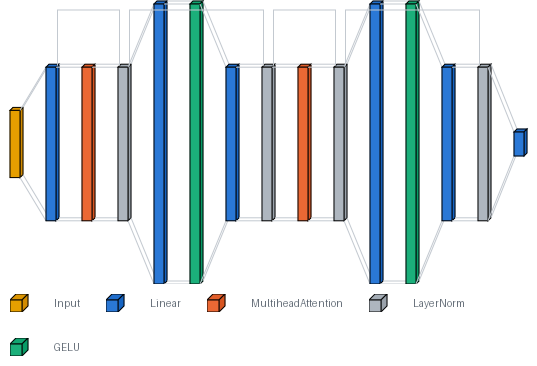

In [4]:
#| label: fig-arch
#| fig-cap: The model end to end. Each patch is projected to 64 numbers, two identical encoder blocks run over the 17 tokens, and the head reads position 0. The tall blue and green pairs are the feed-forward expansion inside each block; the outlines arching over are the residual connections.
#| fig-alt: A left-to-right row of coloured three-dimensional blocks. Two identical groups repeat in the middle, each with an orange attention block and a taller blue and green pair, with thin outlined rectangles arching over them.

diagram(VisionTransformer(), input_shape=(1, 28, 28), style="flow")

## Position Embeddings

Attention compares every token with every other and takes a weighted sum. Nothing
in that calculation refers to *where* a token is, so shuffling the tokens gives the
same outputs in a different order. Without something to break that symmetry a
Vision Transformer sees a bag of patches rather than a picture.

Deleting them measures what they were worth.

In [5]:
_, without_positions = zip(*(train(use_positions=False, seed=s) for s in SEEDS))

def summarise(runs):
    last = [run[-1] for run in runs]
    return f"{np.mean(last):.4f} ({min(last):.4f}-{max(last):.4f})", np.mean(last)

with_text, with_mean = summarise(with_positions)
without_text, without_mean = summarise(without_positions)

print(f"{'':>28} {'mean (min-max) over ' + str(len(SEEDS)) + ' seeds':>26}")
print(f"{'with position embeddings':>28} {with_text:>26}")
print(f"{'without':>28} {without_text:>26}")
print(f"{'difference':>28} {with_mean - without_mean:>+26.4f}")

                             mean (min-max) over 3 seeds
    with position embeddings     0.9402 (0.9353-0.9460)
                     without     0.8649 (0.8500-0.8813)
                  difference                    +0.0753


Removing them costs seven and a half points of accuracy, and the model still gets 86% of digits
right without them. The gap is larger than the spread between seeds, which is what
makes it worth reporting at all.

Plotted against each other, each line the mean of the three runs with the band
showing their spread, and the majority-class baseline underneath:

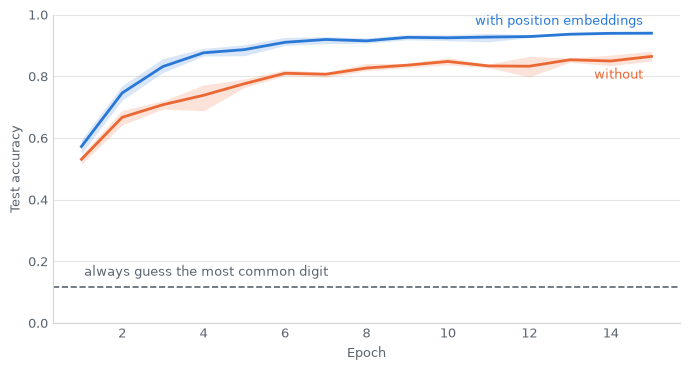

In [6]:
#| label: fig-positions
#| fig-cap: The same model with and without position embeddings. A bag of patches still says a lot about which digit it is; the layout is worth the rest.
#| fig-alt: Two accuracy curves rising over fifteen epochs, each with a narrow shaded band around it showing the spread across three seeds. The curve with position embeddings settles above the one without and their bands do not overlap. Both sit far above a dashed baseline near the bottom.

epochs = range(1, len(with_positions[0]) + 1)
fig, ax = figure(height=3.8)
ax.axhline(baseline, color=MUTED, linewidth=1.2, linestyle="--")

for runs, colour, label, offset in ((with_positions, COLOURS[0], "with position embeddings", 6),
                                    (without_positions, COLOURS[1], "without", -16)):
    grid = np.array(runs)
    ax.fill_between(epochs, grid.min(0), grid.max(0), color=colour, alpha=0.18, linewidth=0)
    ax.plot(epochs, grid.mean(0), color=colour, linewidth=2)
    ax.annotate(label, xy=(epochs[-1], grid.mean(0)[-1]), xytext=(-6, offset),
                textcoords="offset points", ha="right", fontsize=9, color=colour)
ax.annotate("always guess the most common digit", xy=(1, baseline), xytext=(2, 8),
            textcoords="offset points", fontsize=9, color=MUTED)
ax.set_ylim(0, 1.0)
style_axes(ax, "Epoch", "Test accuracy")
fig.tight_layout()

It still works without them, which surprised me until I thought about what a bag of
7×7 patches contains. A 0 and a 1 are made of visibly different pieces however you
shuffle them. Position buys the distinctions that depend on layout.

Since the classifier reads only the `[CLS]` token, the attention out of that
position says which patches the answer actually rests on.

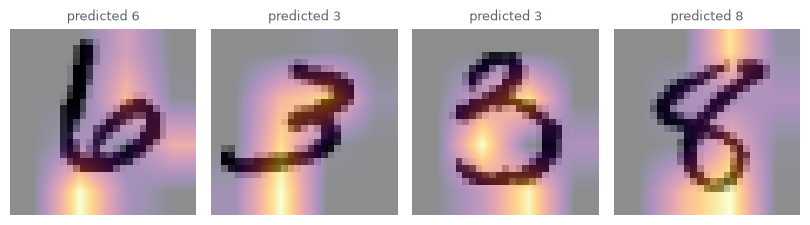

In [7]:
#| label: fig-attention
#| fig-cap: Attention from the [CLS] token in the final block. Nothing in the loss says to look at the strokes.
#| fig-alt: Four handwritten digits in a row, each with a coarse four-by-four heat overlay concentrated on the ink rather than the empty corners.

import matplotlib.pyplot as plt

with torch.no_grad():
    logits, weights = model(x_test[:4], want_weights=True)

cls_attention = weights[:, 0, 1:].reshape(-1, 4, 4)

fig, axes = plt.subplots(1, 4, figsize=(8.2, 2.4))
for ax, image, attention, predicted in zip(axes, x_test[:4], cls_attention, logits.argmax(1)):
    ax.imshow(image, cmap="gray_r")
    ax.imshow(attention, cmap="inferno", alpha=0.45, extent=(0, 28, 28, 0),
              interpolation="bilinear")
    ax.set_title(f"predicted {predicted.item()}", fontsize=9, color=MUTED, pad=6)
    ax.axis("off")
fig.tight_layout()

## Conclusion

The accuracy is not the point. A small convolutional network beats this at MNIST
scale, and the ViT paper says transformers only overtake convolutions with a lot of
data behind them.

What week 3 gives you:

* Why it is called a transformer: it rewrites each token's meaning using context
* Why attention divides by the square root of the width
* An image is a sequence of vectors, the same as a sentence
* The front end is swappable, and the model behind it does not change

Week 4 takes that last point literally and bolts a vision model to a language
model.

The full project, with the blocks written from scratch, is
[on GitHub](https://github.com/RoshBeed/ai-residency/tree/main/services/vit-classifier).
